In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from xgboost import XGBClassifier

# ============================================================
# 1. LOAD & PREPARE DATA
# ============================================================
df_train = pd.read_csv("https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/TrainingData.csv")

# Fjern irrelevante features
irrelevant_cols = ["filnavn", "beta", "snr_db"]
for col in irrelevant_cols:
    if col in df_train.columns:
        df_train = df_train.drop(columns=[col])

# ============================================================
# 2. FILTERING
# ============================================================
# df_train = df_train[...].copy()
# df_train = df_train.dropna(subset=["kolonneNavn"])

# ============================================================
# 3. FEATURES & TARGET
# ============================================================
X = df_train.drop(columns=["target"])
y = df_train["target"]

# Fast klasse-mapping i den ønskede rækkefølge
target_names = [
    "BlueNoise",
    "BrownNoise",
    "Clean",
    "PinkNoise",
    "VioletNoise",
    "WhiteNoise",
]
class_mapping = {name: idx for idx, name in enumerate(target_names)}

unknown_labels = sorted(set(y.unique()) - set(class_mapping.keys()))
if unknown_labels:
    raise ValueError(f"Ukendte klasser i target: {unknown_labels}")

y_encoded = y.map(class_mapping).astype(int)

# LabelEncoder beholdes for kompatibilitet med senere celler
label_encoder = LabelEncoder()
label_encoder.fit(target_names)

print("Klasse mapping:")
for class_name in target_names:
    print(f"{class_name} -> {class_mapping[class_name]}")

# ============================================================
# 4. TRAIN / VALIDATION SPLIT
# ============================================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.20, stratify=y_encoded, random_state=42
)

# ============================================================
# 5. 5-FOLD CV + GRID SEARCH (XGBOOST, SAMLET MODEL)
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

grid_combinations = (
    len(param_grid["n_estimators"]) *
    len(param_grid["max_depth"]) *
    len(param_grid["learning_rate"]) *
    len(param_grid["subsample"]) *
    len(param_grid["colsample_bytree"])
 )
print(f"Grid-kombinationer: {grid_combinations}")
print(f"Model fits i alt (kombinationer x 5 folds): {grid_combinations * 5}")

base_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(target_names),
    random_state=42,
    eval_metric="mlogloss",
    tree_method="hist"
 )

search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=0
)

search.fit(X_train, y_train)

print(f"Best CV Accuracy (5-fold): {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

best_idx = search.best_index_
best_fold_scores = [search.cv_results_[f"split{i}_test_score"][best_idx] for i in range(cv.n_splits)]
print("Fold accuracies for bedste model:")
for i, score in enumerate(best_fold_scores, start=1):
    print(f"Fold {i}: {score:.4f}")
print(f"Mean af fold accuracies: {np.mean(best_fold_scores):.4f}")

model = search.best_estimator_
y_val_pred = model.predict(X_val)

print(f"\nValidation Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred, target_names=target_names, digits=4))

print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val, y_val_pred))

Klasse mapping:
BlueNoise -> 0
BrownNoise -> 1
Clean -> 2
PinkNoise -> 3
VioletNoise -> 4
WhiteNoise -> 5
Grid-kombinationer: 72
Model fits i alt (kombinationer x 5 folds): 360
Best CV Accuracy (5-fold): 0.9547
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}

Validation Accuracy: 0.9614

Classification Report (Validation):
              precision    recall  f1-score   support

   BlueNoise     0.9437    0.9710    0.9571        69
  BrownNoise     0.9054    0.9710    0.9371        69
       Clean     0.9545    0.9130    0.9333        69
   PinkNoise     1.0000    0.9855    0.9927        69
 VioletNoise     0.9706    0.9565    0.9635        69
  WhiteNoise     1.0000    0.9710    0.9853        69

    accuracy                         0.9614       414
   macro avg     0.9624    0.9614    0.9615       414
weighted avg     0.9624    0.9614    0.9615       414


Confusion Matrix (Validation):
[[67  0  0  0  2  0]
 [ 0 67  2

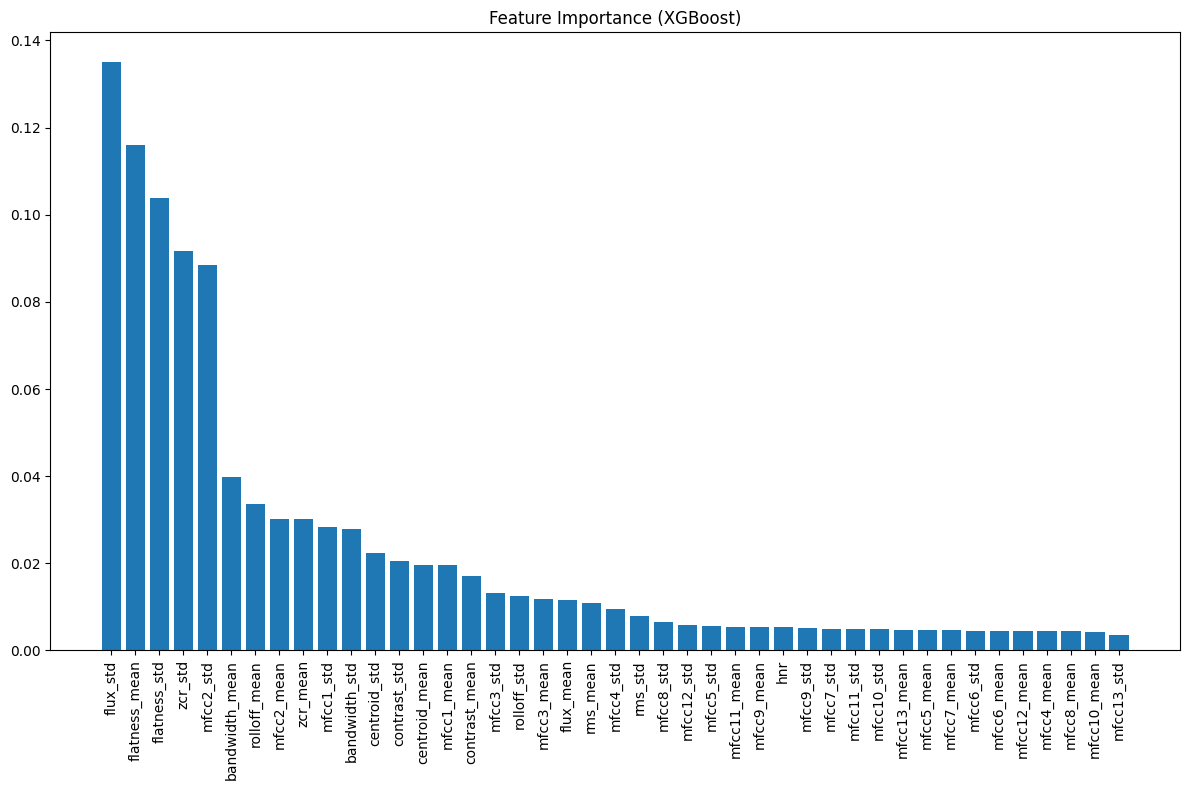


Top 15 vigtigste features:
flux_std: 0.1351
flatness_mean: 0.1160
flatness_std: 0.1038
zcr_std: 0.0918
mfcc2_std: 0.0885
bandwidth_mean: 0.0398
rolloff_mean: 0.0337
mfcc2_mean: 0.0302
zcr_mean: 0.0301
mfcc1_std: 0.0284
bandwidth_std: 0.0279
centroid_std: 0.0224
contrast_std: 0.0205
centroid_mean: 0.0196
mfcc1_mean: 0.0196


In [3]:
# ----------------------------
# 4. FEATURE IMPORTANCE
# ----------------------------
importances = model.feature_importances_
feature_names = X.columns

# Sorter features efter importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title("Feature Importance (XGBoost)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

# Print top 15 vigtigste features
print("\nTop 15 vigtigste features:")
for i in indices[:15]:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

In [4]:
# ----------------------------
# 5. Fjerne features baseret på importance
# ----------------------------

# Sæt en threshold for feature importance
importance_threshold = 0.02  # Juster denne værdi efter behov

# Find features der skal beholdes
features_to_keep = [feature for feature, importance in zip(feature_names, importances) if importance >= importance_threshold]
print(f"Beholder {len(features_to_keep)} features ud af {len(feature_names)} (threshold: {importance_threshold})")

# Fjern features med lav importance fra X
X_reduced = X[features_to_keep]
print("Features efter fjernelse:", X_reduced.columns.tolist())

# Nu kan X_reduced bruges til at træne en ny model eller til videre analyse

Beholder 13 features ud af 43 (threshold: 0.02)
Features efter fjernelse: ['centroid_std', 'bandwidth_mean', 'bandwidth_std', 'rolloff_mean', 'flatness_mean', 'flatness_std', 'zcr_mean', 'zcr_std', 'flux_std', 'contrast_std', 'mfcc1_std', 'mfcc2_mean', 'mfcc2_std']


In [5]:
# ----------------------------
# 6. ERROR ANALYSIS (SNR & BETA)
# ----------------------------

# gem predictions i dataframe
df_analysis = df_test.copy()
df_analysis["y_true"] = y_test_true
df_analysis["y_pred"] = y_test_pred
df_analysis["correct"] = df_analysis["y_true"] == df_analysis["y_pred"]

# behold kun støj (Clean har NaN)
df_noise = df_analysis.dropna(subset=["snr_db", "beta"]).copy()
# fejlrate pr SNR
snr_bins = np.arange(-5, 21, 2)
df_noise["snr_bin"] = pd.cut(df_noise["snr_db"], bins=snr_bins)

snr_error = df_noise.groupby("snr_bin")["correct"].mean()
snr_error = 1 - snr_error

plt.figure(figsize=(8,5))
snr_error.plot(kind="bar")
plt.title("XGBoost Model Error Rate vs SNR")
plt.ylabel("Error Rate")
plt.xlabel("SNR Bin (dB)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# fejlrate pr beta
beta_bins = np.linspace(-2.5, 2.5, 10)
df_noise["beta_bin"] = pd.cut(df_noise["beta"], bins=beta_bins)

beta_error = df_noise.groupby("beta_bin")["correct"].mean()
beta_error = 1 - beta_error

plt.figure(figsize=(8,5))
beta_error.plot(kind="bar")
plt.title("XGBoost Model Error Rate vs Beta")
plt.ylabel("Error Rate")
plt.xlabel("Beta Bin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Lav prediction
y_test_pred = model.predict(X_test)

# Evaluer
print("\nTest Accuracy:", accuracy_score(y_test_true, y_test_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_true, y_test_pred))


# ----------------------------
# ERROR ANALYSIS
# ----------------------------

df_analysis = df_test.copy()

df_analysis["y_true"] = y_test_true
df_analysis["y_pred"] = y_test_pred
df_analysis["correct"] = df_analysis["y_true"] == df_analysis["y_pred"]

df_analysis["true_label"] = label_encoder.inverse_transform(df_analysis["y_true"])
df_analysis["pred_label"] = label_encoder.inverse_transform(df_analysis["y_pred"])

errors = df_analysis[df_analysis["correct"] == False]

print("\nEksempler på fejl:")
print(errors[["true_label","pred_label","beta","snr_db"]].head(20))

NameError: name 'df_test' is not defined